In [1]:
import pandas as pd 
import glob
import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")
from rdkit import Chem
from rdkit.Chem import Descriptors
from tqdm import tqdm
from mordred import Calculator, descriptors
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV)
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,roc_curve, auc, f1_score,
                              matthews_corrcoef, confusion_matrix,
                              classification_report, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

Calculo de los descriptores fisicoquimicos a partir de los SMILES etiquetados anteriormente

In [ ]:
df_final= pd.read_csv('dataset_filtrado_cysteine_protease.csv', sep=';')
df_final['Label'] = (df_final['activity_uM'] < 1 ).astype(int)

mols, valid_idx = [], []

print("Convirtiendo SMILES a objetos moleculares...")
for i, row in df_final.iterrows():
    mol = Chem.MolFromSmiles(row["smiles_std"])
    if mol is not None:
        mols.append(mol)
        valid_idx.append(i)
df_mol = df_final.iloc[valid_idx].reset_index(drop=True)
print(f"Moléculas válidas para Mordred: {len(mols)}")

calc = Calculator(descriptors, ignore_3D=True)
print("Calculando descriptores 2D (esto puede tardar varios minutos)...")
df_desc = calc.pandas(mols)
print(f"Descriptores calculados inicialmente: {df_desc.shape[1]}")

Convirtiendo SMILES a objetos moleculares...
Moléculas válidas para Mordred: 55
Calculando descriptores 2D (esto puede tardar varios minutos)...


100%|██████████| 55/55 [00:07<00:00,  7.33it/s]


Descriptores calculados inicialmente: 1613
   Molecule ChEMBL ID                                         smiles_std  \
0        CHEMBL191457    O=C(Nc1ccc(Cl)cc1)Nc1ccc(C(=O)/C=C/c2ccccc2)cc1   
1        CHEMBL191640  O=C(Nc1ccc(Cl)cc1)Nc1ccc(C(=O)/C=C/c2ccc(F)cc2...   
2        CHEMBL192149  COc1cc(/C=C/C(=O)c2ccc(NC(=O)Nc3ccc(Cl)cc3)cc2...   
3       CHEMBL1939368  CCc1nnc(NC(=O)CCc2ccc(S(=O)(=O)Nc3ccc(F)cc3)cc...   
4        CHEMBL194821  O=C(Nc1ccc(Cl)cc1)Nc1ccc(C(=O)/C=C/c2ccc(Cl)cc...   
5        CHEMBL195381  O=C(Nc1ccc(Cl)cc1)Nc1ccc(C(=O)/C=C/c2ccc3c(c2)...   
6        CHEMBL195822  O=C(Nc1ccc(Cl)cc1)Nc1ccc(C(=O)/C=C/c2ccc(Cl)cc...   
7       CHEMBL2235031  Cc1cc(N/N=C/c2ccc(O[C@H]3O[C@@H]4O[C@@]5(C)CC[...   
8       CHEMBL2235035  Cc1cc(N/N=C/c2ccc(O[C@H]3O[C@@H]4O[C@@]5(C)CC[...   
9       CHEMBL2235036  Cc1cc(N/N=C/c2ccc(O[C@H]3O[C@@H]4O[C@@]5(C)CC[...   
10      CHEMBL2235037  COc1ccc2nc(C)cc(N/N=C/c3ccc(O[C@H]4O[C@@H]5O[C...   
11      CHEMBL2235038  Cc1cc(N/N=C/c2ccc(O[C@

Limpieza de descriptores

In [5]:
# Columnas vacias
df_desc = df_desc.dropna(axis=1, how="all")
# Columnas con >20% NaN
thresh = int(len(df_desc) * 0.8)
df_desc = df_desc.dropna(axis=1, thresh=thresh)
# Solo columnas numericas
df_desc = df_desc.select_dtypes(include=[np.number])
# Imputar NaN restantes con mediana
imputer_init = SimpleImputer(strategy="median")
X_arr = imputer_init.fit_transform(df_desc)
X_full = pd.DataFrame(X_arr, columns=df_desc.columns)
# Varianza cero
vt = VarianceThreshold(threshold=0.0)
X_full = pd.DataFrame(
    vt.fit_transform(X_full),
    columns=X_full.columns[vt.get_support()]
)
y = df_mol["Label"].values
print(f"Descriptores tras limpieza: {X_full.shape[1]}")

X_out = X_full.copy()
X_out.insert(0, "ChEMBL_ID", df_mol["Molecule ChEMBL ID"].values)
X_out["Label"] = y
X_out.to_csv("paso4_descriptores_mordred.csv", index=False)
print(f"✅ paso4_descriptores_mordred.csv guardado.")

Descriptores tras limpieza: 1219
✅ paso4_descriptores_mordred.csv guardado.


In [6]:
def correlation_filter(X: pd.DataFrame, threshold: float,
                        method: str = "pearson") -> list:
    corr_matrix = X.corr(method=method).abs()
    upper= corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
                             )
    to_drop = {col for col in upper.columns if any(upper[col] >= threshold)}
    retained = [col for col in X.columns if col not in to_drop]
    return retained
    
feature_sets = {}   # {"nombre": [lista_columnas_retenidas]}

CORR_THRESHOLDS   = [0.7, 0.8, 0.9]

for thr in CORR_THRESHOLDS:
    for method in ["pearson", "spearman"]:
        key = f"{method}_thr{thr}"
        retained = correlation_filter(X_full, thr, method)
        feature_sets[key] = retained
        print(f"  {key:30s} → {len(retained):4d} descriptores retenidos")

feature_sets["no_filter"] = list(X_full.columns)
print(f"  {'no_filter':30s} → {len(X_full.columns):4d} descriptores (sin filtro)")

pd.DataFrame(
    {"feature_set": list(feature_sets.keys()),
     "n_features":  [len(v) for v in feature_sets.values()]}
).to_csv("paso5_feature_sets.csv", index=False)
print(f"✅ paso5_feature_sets.csv guardado.", sep=';')

  pearson_thr0.7                 →   74 descriptores retenidos
  spearman_thr0.7                →   90 descriptores retenidos
  pearson_thr0.8                 →  175 descriptores retenidos
  spearman_thr0.8                →  201 descriptores retenidos
  pearson_thr0.9                 →  356 descriptores retenidos
  spearman_thr0.9                →  377 descriptores retenidos
  no_filter                      → 1219 descriptores (sin filtro)
✅ paso5_feature_sets.csv guardado.


In [7]:
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y,
    test_size=0.20,
    stratify=y,
    random_state= 42
)
print(f"Train: {len(y_train)} muestras | Test: {len(y_test)} muestras")
print(f"  Train activos: {y_train.sum()} ({y_train.mean():.1%})")
print(f"  Test  activos: {y_test.sum()} ({y_test.mean():.1%})")
 
# ── 6.2 Definición de modelos y rejillas de hiperparámetros ───────────────────
# Cada elemento: (nombre, estimador, param_grid)
# Los parámetros del pipeline se prefiján con 'clf__'
 
MODEL_DEFINITIONS = [
    # 1. Regresión Logística
    (
        "LogisticRegression",
        LogisticRegression(max_iter=1000, random_state=42),
        {
            "clf__C"      : [0.01, 0.1, 1, 10, 100],
            "clf__solver" : ["lbfgs", "liblinear"],
            "clf__penalty": ["l2"],
        }
    ),
    # 2. SVM con kernel RBF
    (
        "SVM_RBF",
        SVC(kernel="rbf", probability=True, random_state=42),
        {
            "clf__C"    : [0.1, 1, 10, 100],
            "clf__gamma": ["scale", "auto", 0.001, 0.01],
        }
    ),
    # 3. SVM lineal
    (
        "SVM_Linear",
        SVC(kernel="linear", probability=True, random_state=42),
        {"clf__C": [0.01, 0.1, 1, 10]}
    ),
    # 4. K-Nearest Neighbors
    (
        "KNeighbors",
        KNeighborsClassifier(),
        {
            "clf__n_neighbors": [3, 5, 7, 11, 15],
            "clf__weights"    : ["uniform", "distance"],
            "clf__metric"     : ["euclidean", "manhattan"],
        }
    ),
    # 5. Árbol de decisión
    (
        "DecisionTree",
        DecisionTreeClassifier(random_state=42),
        {
            "clf__max_depth"       : [3, 5, 7, 10, None],
            "clf__min_samples_split": [2, 5, 10],
            "clf__criterion"       : ["gini", "entropy"],
        }
    ),
    # 6. Random Forest
    (
        "RandomForest",
        RandomForestClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, 20, None],
            "clf__min_samples_split": [2, 5],
            "clf__max_features"    : ["sqrt", "log2"],
        }
    ),
    # 7. Extra Trees
    (
        "ExtraTrees",
        ExtraTreesClassifier(random_state=42, n_jobs=-1),
        {
            "clf__n_estimators"    : [100, 200, 300],
            "clf__max_depth"       : [5, 10, None],
            "clf__min_samples_split": [2, 5],
        }
    ),
    # 8. Gradient Boosting
    (
        "GradientBoosting",
        GradientBoostingClassifier(random_state=42),
        {
            "clf__n_estimators" : [100, 200],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth"    : [3, 5, 7],
        }
    ),
    # 9. AdaBoost
    (
        "AdaBoost",
        AdaBoostClassifier(random_state=42, algorithm="SAMME"),
        {
            "clf__n_estimators" : [50, 100, 200],
            "clf__learning_rate": [0.5, 1.0, 2.0],
        }
    ),
    # 10. Red neuronal (MLP)
    (
        "MLP",
        MLPClassifier(max_iter=500, random_state=42),
        {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64)],
            "clf__alpha"             : [1e-4, 1e-3, 1e-2],
            "clf__activation"        : ["relu", "tanh"],
        }
    ),
    # 11. Naive Bayes
    (
        "NaiveBayes",
        GaussianNB(),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6]}
    ),
    # 12. SGD Classifier
    (
        "SGD",
        SGDClassifier(loss="modified_huber", random_state=42,
                      max_iter=1000),
        {
            "clf__alpha"  : [1e-5, 1e-4, 1e-3, 1e-2],
            "clf__penalty": ["l2", "elasticnet"],
        }
    ),

    (
        "XGBoost",
        XGBClassifier(random_state=42, eval_metric="logloss",
                      use_label_encoder=False, n_jobs=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__max_depth"    : [3, 5, 7],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__subsample"    : [0.8, 1.0],
        }
    ),

    (
        "LightGBM",
        LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
        {
            "clf__n_estimators" : [100, 200, 300],
            "clf__num_leaves"   : [31, 63, 127],
            "clf__learning_rate": [0.05, 0.1, 0.2],
        }
    )
]

Train: 44 muestras | Test: 11 muestras
  Train activos: 13 (29.5%)
  Test  activos: 3 (27.3%)


In [8]:
def evaluate(model, X_tr, X_te, y_tr, y_te):
    """Devuelve dict con métricas en train y test para análisis de overfitting."""
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)
 
    try:
        auc_tr = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
        auc_te = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])
    except AttributeError:
        auc_tr = auc_te = np.nan
 
    return {
        "acc_train"     : accuracy_score(y_tr, y_pred_tr),
        "acc_test"      : accuracy_score(y_te, y_pred_te),
        "f1_train"      : f1_score(y_tr, y_pred_tr),
        "f1_test"       : f1_score(y_te, y_pred_te),
        "roc_auc_train" : auc_tr,
        "roc_auc_test"  : auc_te,
        "mcc_train"     : matthews_corrcoef(y_tr, y_pred_tr),
        "mcc_test"      : matthews_corrcoef(y_te, y_pred_te),
        "precision_test": precision_score(y_te, y_pred_te),
        "recall_test"   : recall_score(y_te, y_pred_te),
        "overfit_gap"   : accuracy_score(y_tr, y_pred_tr) - accuracy_score(y_te, y_pred_te),
    }

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
all_results    = []
best_estimators = {}
 
n_total = len(MODEL_DEFINITIONS) * len(feature_sets)
print(f"\nEntrenando {len(MODEL_DEFINITIONS)} modelos × "
      f"{len(feature_sets)} feature sets = {n_total} experimentos...\n")
 
for fs_name, feat_cols in feature_sets.items():
    if "thr0.7" not in fs_name:
        continue
    X_tr = X_train_full[feat_cols]
    X_te = X_test_full[feat_cols]
 
    for model_name, estimator, param_grid in MODEL_DEFINITIONS:
        key = f"{model_name}__{fs_name}"
        print(f"  ▶ {key}")
 
        # Pipeline: imputación → escalado → clasificador
        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
            ("clf",     estimator),
        ])
 
        gs = GridSearchCV(
            pipe, param_grid,
            cv=cv,
            scoring="roc_auc",
            n_jobs=2,
            refit=True,
            return_train_score=True,
        )
        gs.fit(X_tr, y_train)
        best_estimators[key] = gs.best_estimator_
 
        metrics = evaluate(gs.best_estimator_, X_tr, X_te, y_train, y_test)
        metrics["model"]           = model_name
        metrics["feature_set"]     = fs_name
        metrics["n_features"]      = len(feat_cols)
        metrics["best_params"]     = str(gs.best_params_)
        metrics["cv_roc_auc_mean"] = gs.best_score_
        metrics["cv_roc_auc_std"]  = gs.cv_results_["std_test_score"][gs.best_index_]
 
        all_results.append(metrics)
        print(f"      CV AUC={gs.best_score_:.3f} | "
              f"Test AUC={metrics['roc_auc_test']:.3f} | "
              f"Gap={metrics['overfit_gap']:.3f}")
 
 
df_results = pd.DataFrame(all_results).sort_values("roc_auc_test", ascending=False)
df_results.to_csv(f"paso6_resultados_todos.csv",sep=";",  index=False)
print(f"\n✅ paso6_resultados_todos.csv guardado.")


Entrenando 14 modelos × 7 feature sets = 98 experimentos...

  ▶ LogisticRegression__pearson_thr0.7
      CV AUC=1.000 | Test AUC=1.000 | Gap=0.091
  ▶ SVM_RBF__pearson_thr0.7
      CV AUC=1.000 | Test AUC=0.958 | Gap=-0.023
  ▶ SVM_Linear__pearson_thr0.7
      CV AUC=1.000 | Test AUC=0.958 | Gap=0.091
  ▶ KNeighbors__pearson_thr0.7
      CV AUC=1.000 | Test AUC=0.958 | Gap=0.091
  ▶ DecisionTree__pearson_thr0.7
      CV AUC=0.969 | Test AUC=0.833 | Gap=0.091
  ▶ RandomForest__pearson_thr0.7
      CV AUC=1.000 | Test AUC=0.958 | Gap=0.091
  ▶ ExtraTrees__pearson_thr0.7
      CV AUC=1.000 | Test AUC=1.000 | Gap=0.091
  ▶ GradientBoosting__pearson_thr0.7
      CV AUC=1.000 | Test AUC=0.833 | Gap=0.091
  ▶ AdaBoost__pearson_thr0.7
      CV AUC=1.000 | Test AUC=1.000 | Gap=0.000
  ▶ MLP__pearson_thr0.7
      CV AUC=1.000 | Test AUC=0.917 | Gap=0.091
  ▶ NaiveBayes__pearson_thr0.7
      CV AUC=0.933 | Test AUC=0.938 | Gap=0.091
  ▶ SGD__pearson_thr0.7
      CV AUC=1.000 | Test AUC=0.771 | 

7. Evaluacion y seleccion del modelo 

In [10]:
df_results["score_balanced"] = (
    df_results["roc_auc_test"] - 0.5 * df_results["overfit_gap"].abs()
)
df_results = df_results.sort_values("score_balanced", ascending=False)
df_results.to_csv("paso7_resultados_rankeados.csv",sep=";", index=False)

top5_pearson = (
    df_results[df_results["feature_set"].str.contains("pearson")]
    .sort_values("score_balanced", ascending=False)
    .head(5)
)

top5_spearman = (
    df_results[df_results["feature_set"].str.contains("spearman")]
    .sort_values("score_balanced", ascending=False)
    .head(5)
)

best_row = df_results.iloc[0]
best_key = f"{best_row['model']}__{best_row['feature_set']}"

cols_show = ["model", "feature_set", "n_features", "roc_auc_test", "score_balanced"]
print("\n🏆 TOP 5 MODELOS - MÉTODO PEARSON (THR 0.7):")
print(top5_pearson[cols_show].to_string(index=False))

print("\n🏆 TOP 5 MODELOS - MÉTODO SPEARMAN (THR 0.7):")
print(top5_spearman[cols_show].to_string(index=False))


🏆 TOP 5 MODELOS - MÉTODO PEARSON (THR 0.7):
             model    feature_set  n_features  roc_auc_test  score_balanced
          AdaBoost pearson_thr0.7          74      1.000000        1.000000
LogisticRegression pearson_thr0.7          74      1.000000        0.954545
        ExtraTrees pearson_thr0.7          74      1.000000        0.954545
           XGBoost pearson_thr0.7          74      1.000000        0.954545
           SVM_RBF pearson_thr0.7          74      0.958333        0.946970

🏆 TOP 5 MODELOS - MÉTODO SPEARMAN (THR 0.7):
       model     feature_set  n_features  roc_auc_test  score_balanced
     XGBoost spearman_thr0.7          90      1.000000        1.000000
    AdaBoost spearman_thr0.7          90      1.000000        0.954545
RandomForest spearman_thr0.7          90      1.000000        0.954545
     SVM_RBF spearman_thr0.7          90      0.958333        0.946970
    LightGBM spearman_thr0.7          90      0.958333        0.924242


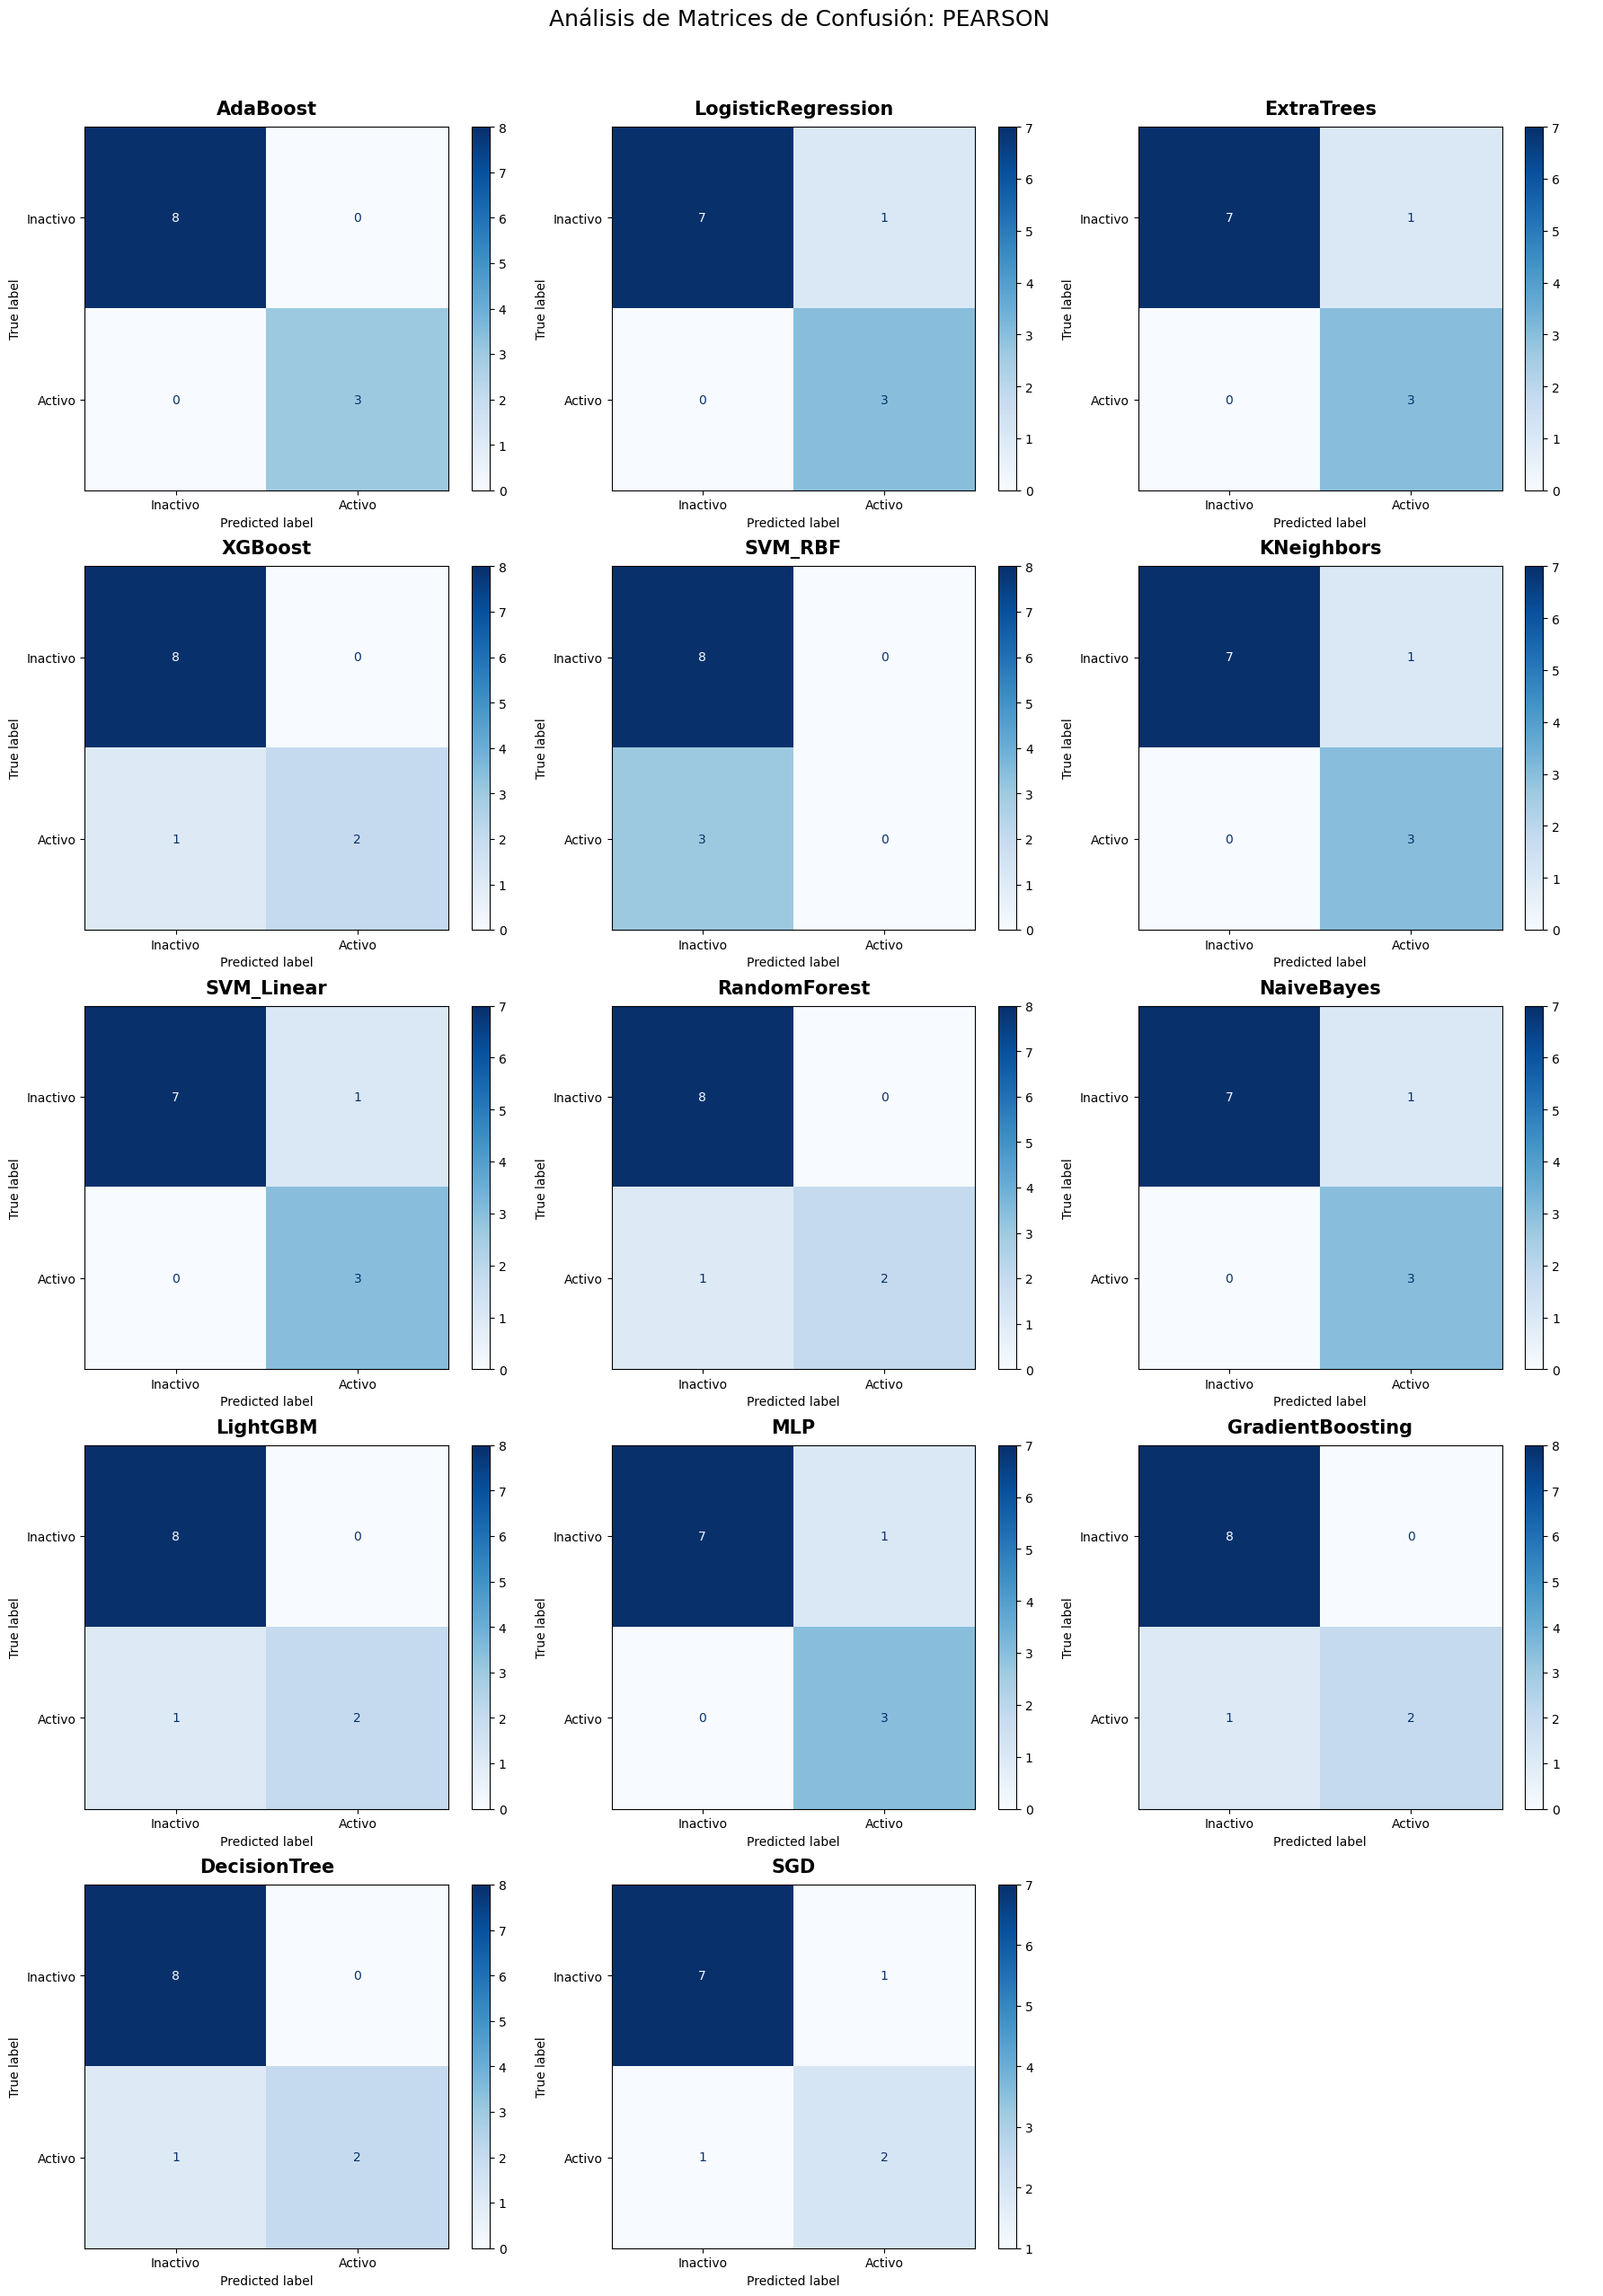

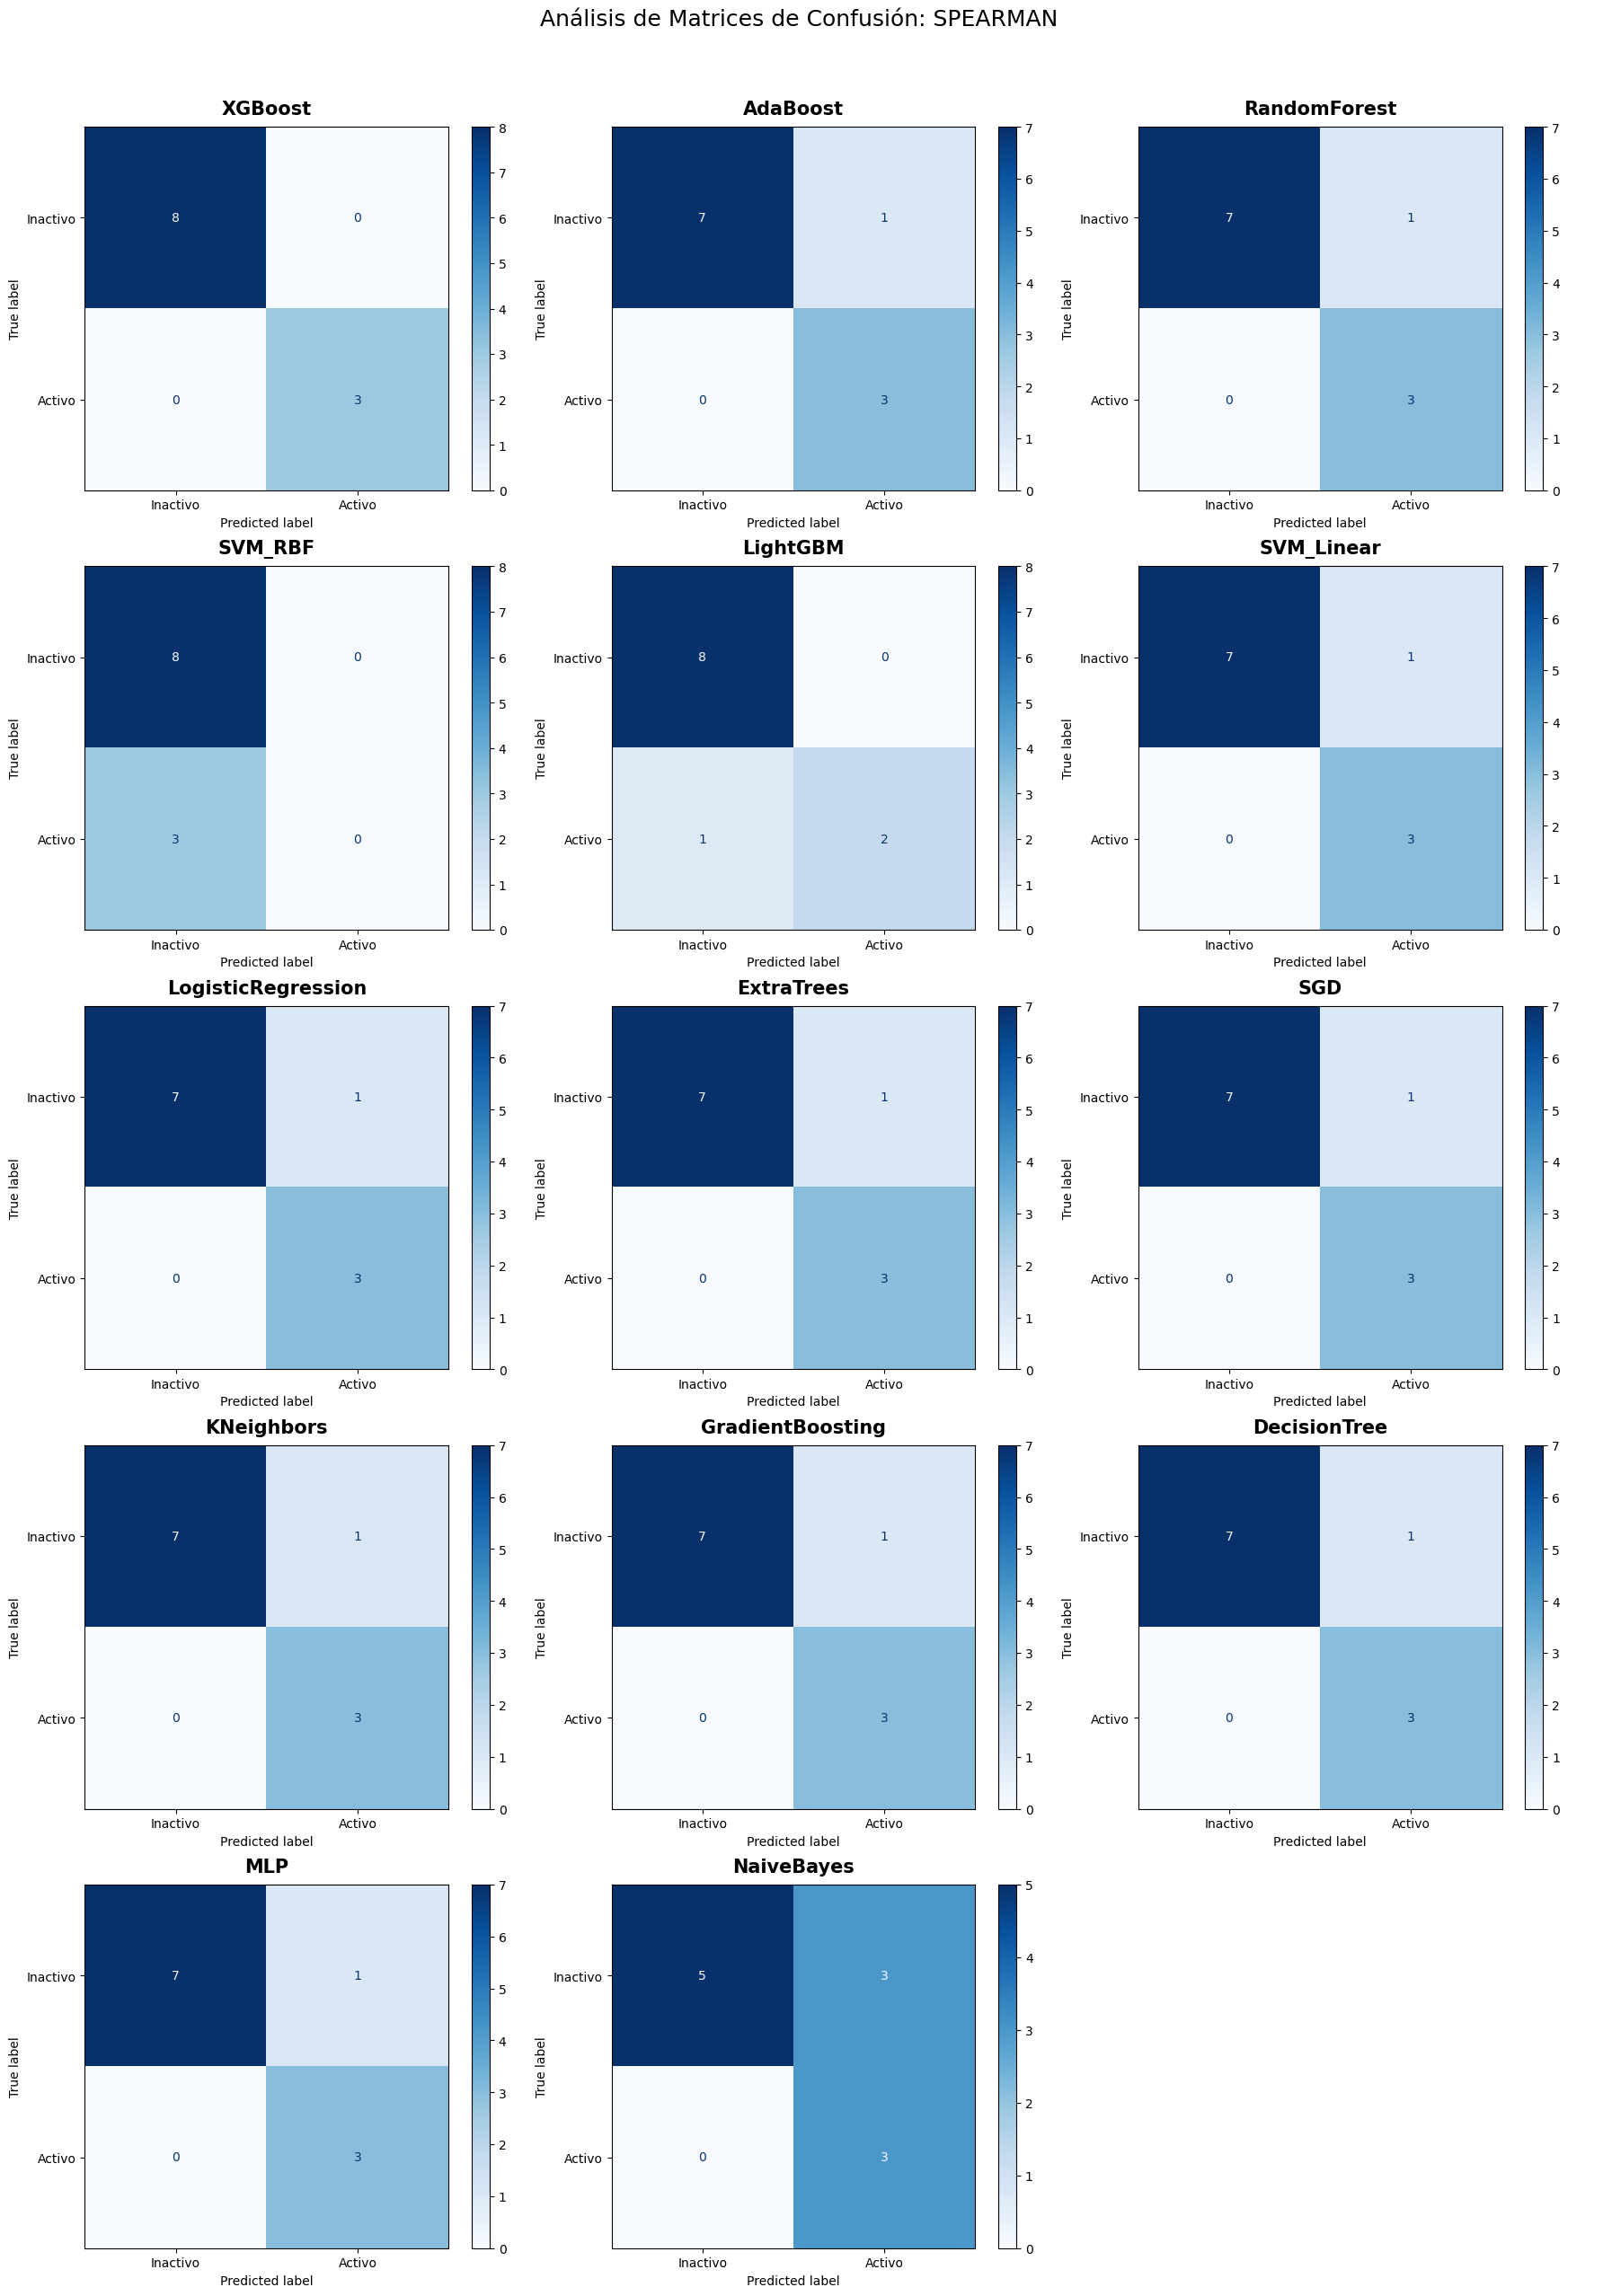

In [11]:
def plot_matrices_final(method_name, results_df, estimators_dict, feature_sets_dict):
    method_results = results_df[results_df["feature_set"].str.contains(method_name, case=False)]
    n_models = len(method_results)
    if n_models == 0: return
    cols = 3
    rows = math.ceil(n_models / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(method_results.iterrows()):
        model_name = row['model']
        fs_name = row['feature_set']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols = feature_sets_dict[fs_name]
        y_pred = est.predict(X_test_full[fs_cols])
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(cm, display_labels=["Inactivo", "Activo"])
        disp.plot(ax=axes[i], colorbar=True, cmap="Blues")
        axes[i].set_title(f"{model_name}", fontsize=15, pad=10,fontweight='bold')
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(f"Análisis de Matrices de Confusión: {method_name.upper()}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f"paso7_confusion_{method_name}_final.png", dpi=150, bbox_inches="tight")
    plt.show()
plot_matrices_final("pearson", df_results, best_estimators, feature_sets)
plot_matrices_final("spearman", df_results, best_estimators, feature_sets)

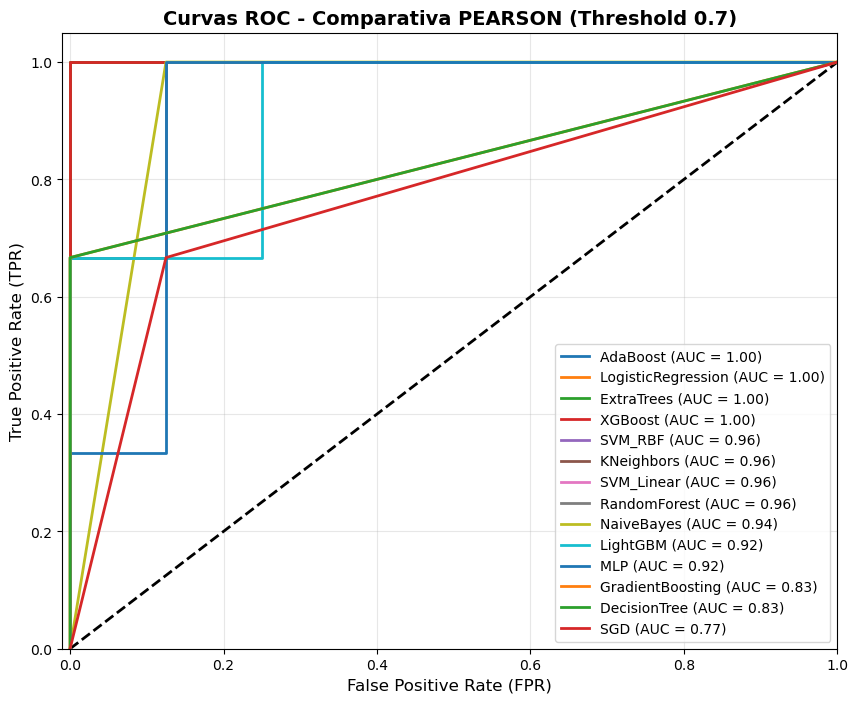

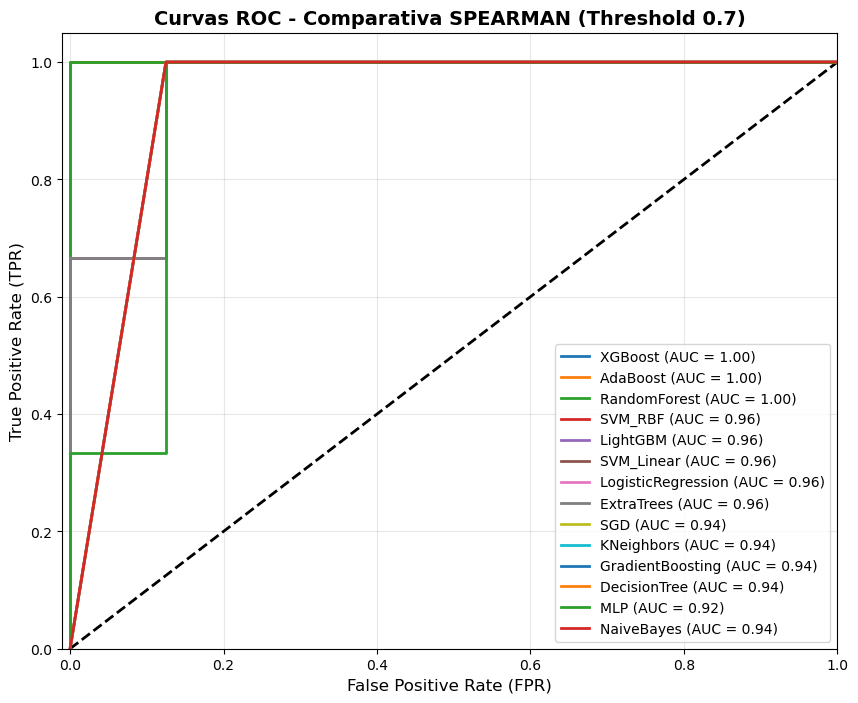

In [12]:
def plot_roc_curves_by_method(method_name, results_df, estimators_dict, feature_sets_dict):
    method_results = results_df[results_df["feature_set"].str.contains(method_name, case=False)]
    plt.figure(figsize=(10, 8))
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    for _, row in method_results.iterrows():
        model_name = row['model']
        fs_name = row['feature_set']
        key = f"{model_name}__{fs_name}"
        est = estimators_dict[key]
        fs_cols = feature_sets_dict[fs_name]
        if hasattr(est, "predict_proba"):
            y_score = est.predict_proba(X_test_full[fs_cols])[:, 1]
        else:
            y_score = est.decision_function(X_test_full[fs_cols])
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{model_name} (AUC = {roc_auc:.2f})')

    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (FPR)', fontsize=12)
    plt.ylabel('True Positive Rate (TPR)', fontsize=12)
    plt.title(f'Curvas ROC - Comparativa {method_name.upper()} (Threshold 0.7)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.savefig(f"paso7_roc_comparison_{method_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

# Ejecutar para Pearson y Spearman
plot_roc_curves_by_method("pearson", df_results, best_estimators, feature_sets)
plot_roc_curves_by_method("spearman", df_results, best_estimators, feature_sets)

In [13]:
pivot_auc = df_results.pivot_table(
    index="model", columns="feature_set",
    values="roc_auc_test", aggfunc="max"
)
fig, ax = plt.subplots(figsize=(14, 6))
pivot_auc.plot(kind="bar", ax=ax, edgecolor="white")
ax.axhline(0.8, color="red", linestyle="--", linewidth=1, label="0.8")
ax.set_title("ROC-AUC (Test) por Modelo y Feature Set")
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("")
ax.legend(title="Feature Set", bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("paso7_comparacion_modelos.png",
            dpi=150, bbox_inches="tight")
plt.close()

In [14]:
pivot_gap = df_results.pivot_table(
    index="model", columns="feature_set",
    values="overfit_gap", aggfunc="min"
)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot_gap, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Overfit Gap (acc_train − acc_test)")
plt.tight_layout()
plt.savefig("paso7_overfit_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.close()

In [15]:
best_est = best_estimators[best_key]
best_fs  = feature_sets[best_row["feature_set"]]
y_pred   = best_est.predict(X_test_full[best_fs])
 
print(f"\n{'='*60}")
print(f"MEJOR MODELO : {best_row['model']}")
print(f"Feature set  : {best_row['feature_set']} ({int(best_row['n_features'])} descriptores)")
print(f"{'='*60}")
print(classification_report(y_test, y_pred, target_names=["Inactivo", "Activo"]))
print(f"MCC = {matthews_corrcoef(y_test, y_pred):.4f}")
try:
    y_prob = best_est.predict_proba(X_test_full[best_fs])[:, 1]
    print(f"ROC-AUC = {roc_auc_score(y_test, y_prob):.4f}")
except AttributeError:
    pass
 
pd.DataFrame(
    classification_report(y_test, y_pred,
                           target_names=["Inactivo", "Activo"],
                           output_dict=True)
).T.to_csv("paso7_report_mejor_modelo.csv")
 
print(f"\n✅ Gráficos y reportes del paso 7 guardados.")


MEJOR MODELO : XGBoost
Feature set  : spearman_thr0.7 (90 descriptores)
              precision    recall  f1-score   support

    Inactivo       1.00      1.00      1.00         8
      Activo       1.00      1.00      1.00         3

    accuracy                           1.00        11
   macro avg       1.00      1.00      1.00        11
weighted avg       1.00      1.00      1.00        11

MCC = 1.0000
ROC-AUC = 1.0000

✅ Gráficos y reportes del paso 7 guardados.


# DOMINIO DE APLICABILIDAD – Leverage / Williams Plot

El **dominio de aplicabilidad (AD)** define el espacio químico en el que el modelo es fiable.
Compuestos fuera del AD deben interpretarse con cautela aunque el modelo haga una predicción.

### Método: Leverage (hat matrix)
- El **leverage** $h_i$ de un compuesto mide su distancia al centroide del espacio de descriptores del training set.
- El **umbral de warning** $h^* = 3(k+1)/n$, donde $k$ = nº de descriptores y $n$ = nº de compuestos de entrenamiento.
- Un compuesto con $h_i > h^*$ está **fuera del AD** (influencia excesiva).
- El **Williams Plot** representa $h_i$ vs residuos estandarizados $\sigma_i$:
  - $h_i > h^*$ → fuera del AD estructural
  - $|\sigma_i| > 3$ → outlier en la respuesta

TOP 3 MODELOS SELECCIONADOS PARA EL DOMINIO DE APLICABILIDAD
             model     feature_set  n_features  roc_auc_test  score_balanced
           XGBoost spearman_thr0.7          90           1.0        1.000000
          AdaBoost  pearson_thr0.7          74           1.0        1.000000
LogisticRegression  pearson_thr0.7          74           1.0        0.954545


[1/3] MODELO : XGBoost
       Feature set : spearman_thr0.7 (90 descriptores)

Descriptores (k)          : 90
Compuestos train (n)      : 44
Umbral h* = 3(k+1)/n      : 6.2045

Train – dentro del AD     : 44 (100.0%)
Train – fuera del AD      : 0 (0.0%)

Test  – dentro del AD     : 11 (100.0%)
Test  – fuera del AD      : 0 (0.0%)

Desviación estándar residuos train : 0.0822
Residuos train |σ| > 3             : 0
Residuos test  |σ| > 3             : 2


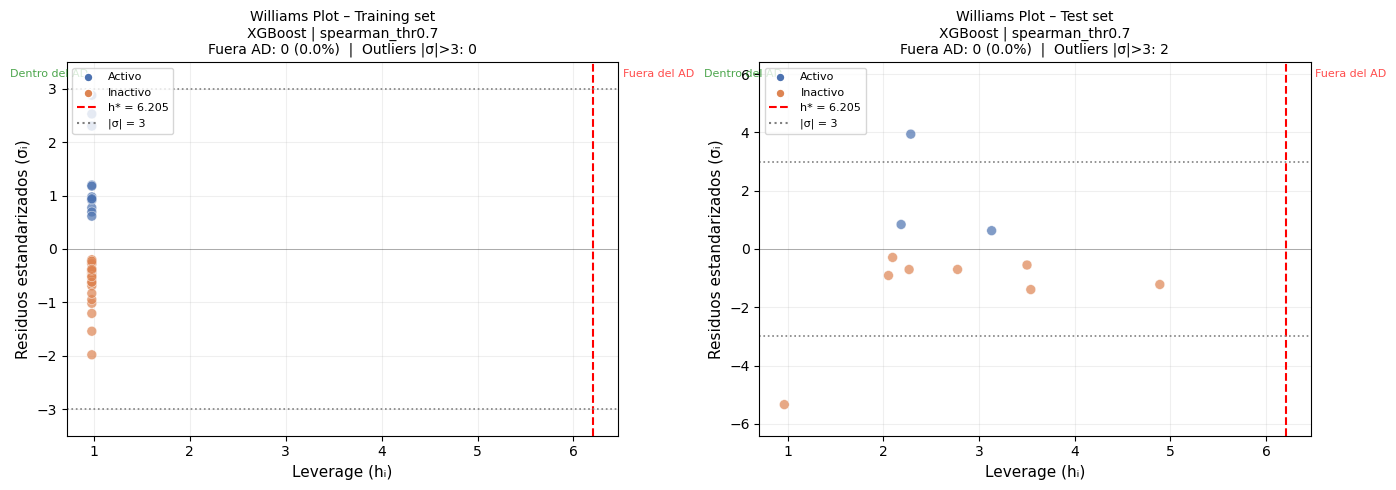

✅ paso8_williams_plot_top1_XGBoost.png guardado.

── Test completo (n=11) ──
  Accuracy  : 1.0000
  F1        : 1.0000
  MCC       : 1.0000
  ROC-AUC   : 1.0000

── Test dentro del AD (n=11) ──
  Accuracy  : 1.0000
  F1        : 1.0000
  MCC       : 1.0000
  ROC-AUC   : 1.0000

── Test fuera del AD (n=0) ──
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000

            subset  n  accuracy  f1  mcc  roc_auc   model     feature_set
     Test completo 11       1.0 1.0  1.0      1.0 XGBoost spearman_thr0.7
Test dentro del AD 11       1.0 1.0  1.0      1.0 XGBoost spearman_thr0.7
 Test fuera del AD  0       NaN 0.0  0.0      NaN XGBoost spearman_thr0.7
✅ paso8_ad_metrics_top1_XGBoost.csv guardado.


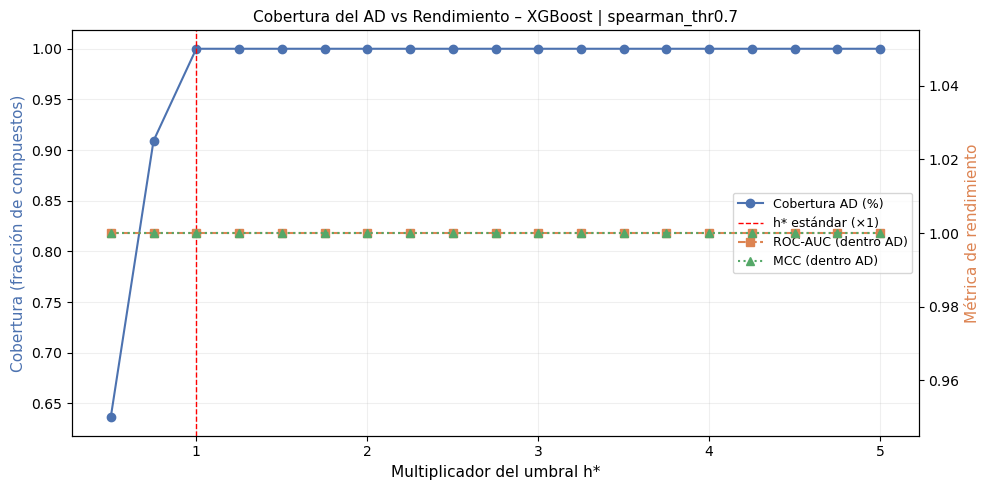

✅ paso8_ad_coverage_top1_XGBoost.png guardado.
split  in_AD
test   1        11
train  1        44
✅ paso8_leverage_top1_XGBoost.csv guardado.

[2/3] MODELO : AdaBoost
       Feature set : pearson_thr0.7 (74 descriptores)

Descriptores (k)          : 74
Compuestos train (n)      : 44
Umbral h* = 3(k+1)/n      : 5.1136

Train – dentro del AD     : 44 (100.0%)
Train – fuera del AD      : 0 (0.0%)

Test  – dentro del AD     : 11 (100.0%)
Test  – fuera del AD      : 0 (0.0%)

Desviación estándar residuos train : 0.1902
Residuos train |σ| > 3             : 0
Residuos test  |σ| > 3             : 0


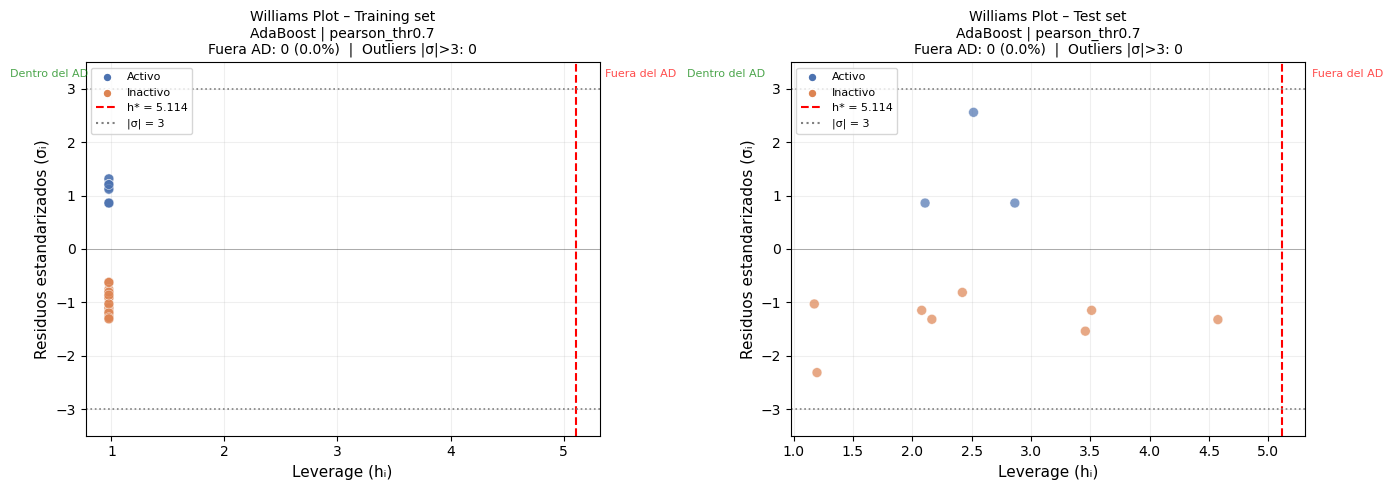

✅ paso8_williams_plot_top2_AdaBoost.png guardado.

── Test completo (n=11) ──
  Accuracy  : 1.0000
  F1        : 1.0000
  MCC       : 1.0000
  ROC-AUC   : 1.0000

── Test dentro del AD (n=11) ──
  Accuracy  : 1.0000
  F1        : 1.0000
  MCC       : 1.0000
  ROC-AUC   : 1.0000

── Test fuera del AD (n=0) ──
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000

            subset  n  accuracy  f1  mcc  roc_auc    model    feature_set
     Test completo 11       1.0 1.0  1.0      1.0 AdaBoost pearson_thr0.7
Test dentro del AD 11       1.0 1.0  1.0      1.0 AdaBoost pearson_thr0.7
 Test fuera del AD  0       NaN 0.0  0.0      NaN AdaBoost pearson_thr0.7
✅ paso8_ad_metrics_top2_AdaBoost.csv guardado.


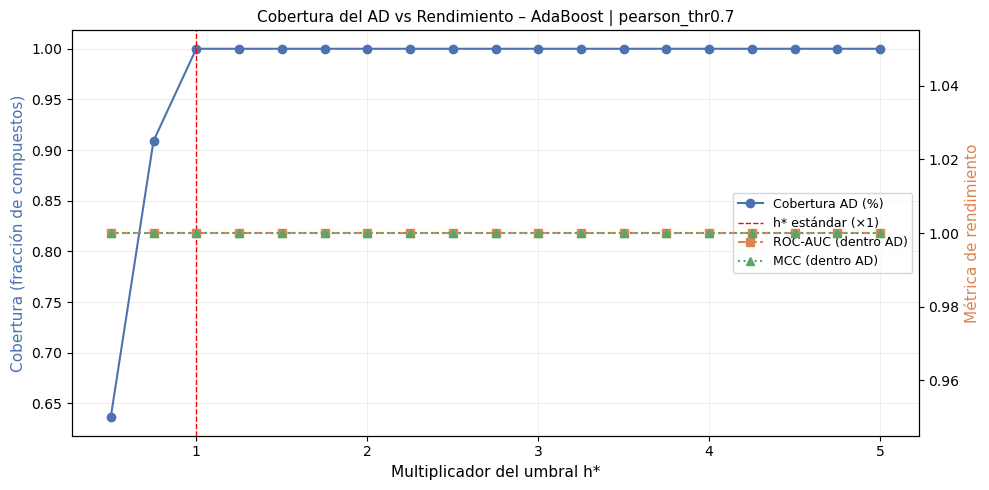

✅ paso8_ad_coverage_top2_AdaBoost.png guardado.
split  in_AD
test   1        11
train  1        44
✅ paso8_leverage_top2_AdaBoost.csv guardado.

[3/3] MODELO : LogisticRegression
       Feature set : pearson_thr0.7 (74 descriptores)

Descriptores (k)          : 74
Compuestos train (n)      : 44
Umbral h* = 3(k+1)/n      : 5.1136

Train – dentro del AD     : 44 (100.0%)
Train – fuera del AD      : 0 (0.0%)

Test  – dentro del AD     : 11 (100.0%)
Test  – fuera del AD      : 0 (0.0%)

Desviación estándar residuos train : 0.1228
Residuos train |σ| > 3             : 0
Residuos test  |σ| > 3             : 1


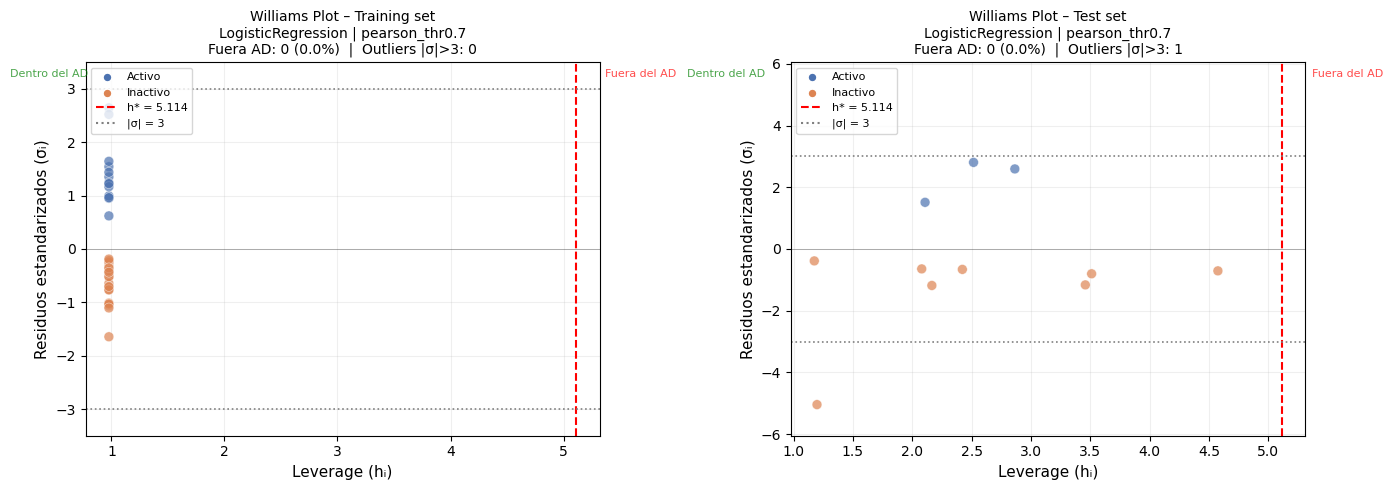

✅ paso8_williams_plot_top3_LogisticRegression.png guardado.

── Test completo (n=11) ──
  Accuracy  : 0.9091
  F1        : 0.8571
  MCC       : 0.8101
  ROC-AUC   : 1.0000

── Test dentro del AD (n=11) ──
  Accuracy  : 0.9091
  F1        : 0.8571
  MCC       : 0.8101
  ROC-AUC   : 1.0000

── Test fuera del AD (n=0) ──
  Accuracy  : nan
  F1        : 0.0000
  MCC       : 0.0000

            subset  n  accuracy       f1      mcc  roc_auc              model    feature_set
     Test completo 11  0.909091 0.857143 0.810093      1.0 LogisticRegression pearson_thr0.7
Test dentro del AD 11  0.909091 0.857143 0.810093      1.0 LogisticRegression pearson_thr0.7
 Test fuera del AD  0       NaN 0.000000 0.000000      NaN LogisticRegression pearson_thr0.7
✅ paso8_ad_metrics_top3_LogisticRegression.csv guardado.


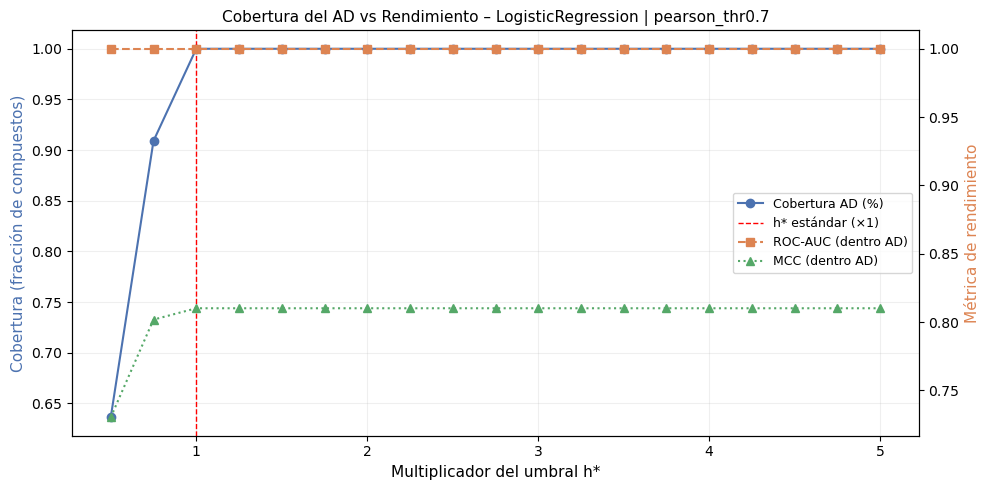

✅ paso8_ad_coverage_top3_LogisticRegression.png guardado.
split  in_AD
test   1        11
train  1        44
✅ paso8_leverage_top3_LogisticRegression.csv guardado.

RESUMEN COMPARATIVO – TOP 3 MODELOS
 rank              model     feature_set  h_star  pct_in_AD  roc_auc_all  roc_auc_in_AD  mcc_all  mcc_in_AD
    1            XGBoost spearman_thr0.7  6.2045      100.0          1.0            1.0   1.0000     1.0000
    2           AdaBoost  pearson_thr0.7  5.1136      100.0          1.0            1.0   1.0000     1.0000
    3 LogisticRegression  pearson_thr0.7  5.1136      100.0          1.0            1.0   0.8101     0.8101

✅ paso8_summary_top3.csv guardado.


In [16]:
# =============================================================================
# PASO 8 – DOMINIO DE APLICABILIDAD (TOP 3 MODELOS)
# Leverage / Williams Plot
# =============================================================================
# Prerrequisitos en memoria (del paso 7):
#   df_results, best_estimators, feature_sets
#   X_train_full, X_test_full, y_train, y_test, df_mol
# =============================================================================

# ── Función auxiliar de leverage ─────────────────────────────────────────────
def compute_leverage(X, XtX_inv):
    """h_i = x_i (X'X)^-1 x_i' para cada fila x_i."""
    return np.array([x @ XtX_inv @ x for x in X])

# ── Función auxiliar de métricas ─────────────────────────────────────────────
def metrics_summary(y_true, y_pred, y_prob, label):
    print(f"\n── {label} (n={len(y_true)}) ──")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  MCC       : {matthews_corrcoef(y_true, y_pred):.4f}")
    if len(np.unique(y_true)) > 1:
        print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    return {
        'subset'  : label,
        'n'       : len(y_true),
        'accuracy': accuracy_score(y_true, y_pred),
        'f1'      : f1_score(y_true, y_pred),
        'mcc'     : matthews_corrcoef(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_prob)
                    if len(np.unique(y_true)) > 1 else np.nan,
    }

# ── Seleccionar los 3 mejores modelos ────────────────────────────────────────
top3 = df_results.head(3).reset_index(drop=True)

print("=" * 60)
print("TOP 3 MODELOS SELECCIONADOS PARA EL DOMINIO DE APLICABILIDAD")
print("=" * 60)
cols_show = ["model", "feature_set", "n_features",
             "roc_auc_test", "score_balanced"]
print(top3[cols_show].to_string(index=False))
print()

# =============================================================================
# BUCLE PRINCIPAL – un AD completo por cada modelo del top 3
# =============================================================================
for rank, best_row in top3.iterrows():
    rank      += 1                        # 1-based
    best_key   = f"{best_row['model']}__{best_row['feature_set']}"
    best_est   = best_estimators[best_key]
    fs_cols    = feature_sets[best_row['feature_set']]
    model_tag  = f"top{rank}_{best_row['model']}"

    print("\n" + "=" * 60)
    print(f"[{rank}/3] MODELO : {best_row['model']}")
    print(f"       Feature set : {best_row['feature_set']} "
          f"({int(best_row['n_features'])} descriptores)")
    print("=" * 60)

    # ── Escalar con el preprocessor del pipeline ──────────────────────────
    preprocessor = best_est[:-1]          # imputer + scaler
    X_tr_scaled  = preprocessor.transform(X_train_full[fs_cols])
    X_te_scaled  = preprocessor.transform(X_test_full[fs_cols])

    # ── Hat matrix  H = X(X'X)^-1 X' ─────────────────────────────────────
    XtX_inv = np.linalg.pinv(X_tr_scaled.T @ X_tr_scaled)
    h_train  = compute_leverage(X_tr_scaled, XtX_inv)
    h_test   = compute_leverage(X_te_scaled, XtX_inv)

    # ── Umbral de warning  h* = 3(k+1)/n ──────────────────────────────────
    k      = X_tr_scaled.shape[1]
    n      = X_tr_scaled.shape[0]
    h_star = 3 * (k + 1) / n

    print(f"\nDescriptores (k)          : {k}")
    print(f"Compuestos train (n)      : {n}")
    print(f"Umbral h* = 3(k+1)/n      : {h_star:.4f}")
    print()
    print(f"Train – dentro del AD     : {(h_train <= h_star).sum()} "
          f"({(h_train <= h_star).mean():.1%})")
    print(f"Train – fuera del AD      : {(h_train > h_star).sum()} "
          f"({(h_train > h_star).mean():.1%})")
    print()
    print(f"Test  – dentro del AD     : {(h_test <= h_star).sum()} "
          f"({(h_test <= h_star).mean():.1%})")
    print(f"Test  – fuera del AD      : {(h_test > h_star).sum()} "
          f"({(h_test > h_star).mean():.1%})")

    # ── Residuos estandarizados ───────────────────────────────────────────
    y_prob_train = best_est.predict_proba(X_train_full[fs_cols])[:, 1]
    y_prob_test  = best_est.predict_proba(X_test_full[fs_cols])[:, 1]

    res_train   = y_train - y_prob_train
    res_test    = y_test  - y_prob_test
    std_res     = res_train.std()
    sigma_train = res_train / std_res
    sigma_test  = res_test  / std_res

    print(f"\nDesviación estándar residuos train : {std_res:.4f}")
    print(f"Residuos train |σ| > 3             : {(np.abs(sigma_train) > 3).sum()}")
    print(f"Residuos test  |σ| > 3             : {(np.abs(sigma_test)  > 3).sum()}")

    # ── Williams Plot ──────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (h, sigma, y_lbl, split_name) in zip(
        axes,
        [
            (h_train, sigma_train, y_train, 'Training set'),
            (h_test,  sigma_test,  y_test,  'Test set'),
        ]
    ):
        out_ad      = h > h_star
        outlier_res = np.abs(sigma) > 3
        colors      = np.where(y_lbl == 1, '#4C72B0', '#DD8452')

        ax.scatter(h, sigma, c=colors, alpha=0.7,
                   edgecolors='white', linewidths=0.4, s=50, zorder=3)

        ax.axvline(h_star, color='red', linestyle='--', linewidth=1.5,
                   label=f'h* = {h_star:.3f}')
        ax.axhline( 3, color='gray', linestyle=':', linewidth=1.2, label='|σ| = 3')
        ax.axhline(-3, color='gray', linestyle=':', linewidth=1.2)
        ax.axhline( 0, color='black', linewidth=0.5, alpha=0.4)

        ylim = max(np.abs(sigma).max() * 1.2, 3.5)
        ax.set_ylim(-ylim, ylim)
        ax.text(h_star * 0.02, ylim * 0.92,
                'Dentro del AD', fontsize=8, color='green', alpha=0.7)
        ax.text(h_star * 1.05, ylim * 0.92,
                'Fuera del AD',  fontsize=8, color='red',   alpha=0.7)

        legend_patches = [
            plt.scatter([], [], c='#4C72B0', s=40,
                        label='Activo',   edgecolors='white'),
            plt.scatter([], [], c='#DD8452', s=40,
                        label='Inactivo', edgecolors='white'),
        ]
        ax.legend(handles=legend_patches + [
            plt.Line2D([0], [0], color='red',  linestyle='--',
                       label=f'h* = {h_star:.3f}'),
            plt.Line2D([0], [0], color='gray', linestyle=':',
                       label='|σ| = 3'),
        ], fontsize=8, loc='upper left')

        ax.set_xlabel('Leverage (hᵢ)', fontsize=11)
        ax.set_ylabel('Residuos estandarizados (σᵢ)', fontsize=11)
        ax.set_title(
            f'Williams Plot – {split_name}\n'
            f'{best_row["model"]} | {best_row["feature_set"]}\n'
            f'Fuera AD: {out_ad.sum()} ({out_ad.mean():.1%})  |  '
            f'Outliers |σ|>3: {outlier_res.sum()}',
            fontsize=10
        )
        ax.grid(alpha=0.2)

    plt.tight_layout()
    out_williams = f'paso8_williams_plot_{model_tag}.png'
    plt.savefig(out_williams, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ {out_williams} guardado.')

    # ── Métricas dentro / fuera del AD ────────────────────────────────────
    y_pred_test = best_est.predict(X_test_full[fs_cols])
    mask_ad     = h_test <= h_star

    r_all = metrics_summary(y_test,
                             y_pred_test,
                             y_prob_test,
                             'Test completo')
    r_ad  = metrics_summary(y_test[mask_ad],
                             y_pred_test[mask_ad],
                             y_prob_test[mask_ad],
                             'Test dentro del AD')
    r_out = metrics_summary(y_test[~mask_ad],
                             y_pred_test[~mask_ad],
                             y_prob_test[~mask_ad],
                             'Test fuera del AD')

    df_ad_metrics = pd.DataFrame([r_all, r_ad, r_out])
    df_ad_metrics['model']       = best_row['model']
    df_ad_metrics['feature_set'] = best_row['feature_set']
    out_metrics = f'paso8_ad_metrics_{model_tag}.csv'
    df_ad_metrics.to_csv(out_metrics, index=False)
    print(f"\n{df_ad_metrics.to_string(index=False)}")
    print(f'✅ {out_metrics} guardado.')

    # ── Cobertura del AD vs rendimiento ───────────────────────────────────
    multipliers  = np.arange(0.5, 5.1, 0.25)
    coverages, aucs, mccs = [], [], []

    for mult in multipliers:
        h_threshold = mult * (3 * (k + 1) / n)
        mask        = h_test <= h_threshold
        coverages.append(mask.mean())

        if mask.sum() > 5 and len(np.unique(y_test[mask])) > 1:
            aucs.append(roc_auc_score(y_test[mask], y_prob_test[mask]))
            mccs.append(matthews_corrcoef(y_test[mask], y_pred_test[mask]))
        else:
            aucs.append(np.nan)
            mccs.append(np.nan)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()

    ax1.plot(multipliers, coverages, 'o-',  color='#4C72B0',
             label='Cobertura AD (%)')
    ax2.plot(multipliers, aucs,      's--', color='#DD8452',
             label='ROC-AUC (dentro AD)')
    ax2.plot(multipliers, mccs,      '^:',  color='#55A868',
             label='MCC (dentro AD)')
    ax1.axvline(1.0, color='red', linestyle='--', linewidth=1,
                label='h* estándar (×1)')

    ax1.set_xlabel('Multiplicador del umbral h*', fontsize=11)
    ax1.set_ylabel('Cobertura (fracción de compuestos)',
                   fontsize=11, color='#4C72B0')
    ax2.set_ylabel('Métrica de rendimiento',
                   fontsize=11, color='#DD8452')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               fontsize=9, loc='center right')
    ax1.set_title(
        f'Cobertura del AD vs Rendimiento – {best_row["model"]} | '
        f'{best_row["feature_set"]}',
        fontsize=11
    )
    ax1.grid(alpha=0.2)
    plt.tight_layout()
    out_cov = f'paso8_ad_coverage_{model_tag}.png'
    plt.savefig(out_cov, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ {out_cov} guardado.')

    # ── CSV por compuesto ─────────────────────────────────────────────────
    train_idx = X_train_full.index
    test_idx  = X_test_full.index

    df_ad_train = pd.DataFrame({
        'ChEMBL_ID'  : df_mol.loc[train_idx, 'Molecule ChEMBL ID'].values,
        'split'      : 'train',
        'leverage'   : h_train,
        'sigma'      : sigma_train,
        'label'      : y_train,
        'in_AD'      : (h_train <= h_star).astype(int),
        'outlier_res': (np.abs(sigma_train) > 3).astype(int),
        'model'      : best_row['model'],
        'feature_set': best_row['feature_set'],
    })
    df_ad_test = pd.DataFrame({
        'ChEMBL_ID'  : df_mol.loc[test_idx, 'Molecule ChEMBL ID'].values,
        'split'      : 'test',
        'leverage'   : h_test,
        'sigma'      : sigma_test,
        'label'      : y_test,
        'in_AD'      : (h_test <= h_star).astype(int),
        'outlier_res': (np.abs(sigma_test) > 3).astype(int),
        'model'      : best_row['model'],
        'feature_set': best_row['feature_set'],
    })

    df_ad_all = pd.concat([df_ad_train, df_ad_test], ignore_index=True)
    out_lev   = f'paso8_leverage_{model_tag}.csv'
    df_ad_all.to_csv(out_lev, index=False)
    print(df_ad_all.groupby(['split', 'in_AD'])
                   .size().rename('n_compuestos').to_string())
    print(f'✅ {out_lev} guardado.')

# =============================================================================
# TABLA RESUMEN COMPARATIVA DE LOS 3 MODELOS
# =============================================================================
print("\n" + "=" * 60)
print("RESUMEN COMPARATIVO – TOP 3 MODELOS")
print("=" * 60)

summary_rows = []
for rank, best_row in top3.iterrows():
    rank     += 1
    best_key  = f"{best_row['model']}__{best_row['feature_set']}"
    best_est  = best_estimators[best_key]
    fs_cols   = feature_sets[best_row['feature_set']]
    model_tag = f"top{rank}_{best_row['model']}"

    preprocessor = best_est[:-1]
    X_tr_scaled  = preprocessor.transform(X_train_full[fs_cols])
    X_te_scaled  = preprocessor.transform(X_test_full[fs_cols])
    XtX_inv      = np.linalg.pinv(X_tr_scaled.T @ X_tr_scaled)
    h_test_s     = compute_leverage(X_te_scaled, XtX_inv)
    k, n         = X_tr_scaled.shape[1], X_tr_scaled.shape[0]
    h_star_s     = 3 * (k + 1) / n
    mask_ad_s    = h_test_s <= h_star_s

    y_pred_test  = best_est.predict(X_test_full[fs_cols])
    y_prob_test  = best_est.predict_proba(X_test_full[fs_cols])[:, 1]

    summary_rows.append({
        'rank'          : rank,
        'model'         : best_row['model'],
        'feature_set'   : best_row['feature_set'],
        'h_star'        : round(h_star_s, 4),
        'pct_in_AD'     : round(mask_ad_s.mean() * 100, 1),
        'roc_auc_all'   : round(roc_auc_score(y_test, y_prob_test), 4),
        'roc_auc_in_AD' : round(roc_auc_score(y_test[mask_ad_s],
                                               y_prob_test[mask_ad_s]), 4)
                          if mask_ad_s.sum() > 0 and
                             len(np.unique(y_test[mask_ad_s])) > 1
                          else np.nan,
        'mcc_all'       : round(matthews_corrcoef(y_test, y_pred_test), 4),
        'mcc_in_AD'     : round(matthews_corrcoef(y_test[mask_ad_s],
                                                   y_pred_test[mask_ad_s]), 4)
                          if mask_ad_s.sum() > 0 else np.nan,
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv('paso8_summary_top3.csv', index=False)
print(df_summary.to_string(index=False))
print('\n✅ paso8_summary_top3.csv guardado.')